In [4]:
!pip install h2o -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import h2o
from h2o.automl import H2OAutoML
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
df = pd.read_csv('train.csv')
print("Dataset Shape:", df.shape)
print("\nTarget Variable Distribution:")
print(df['loan_default'].value_counts())
print("\nDefault Rate: {:.2f}%".format(df['loan_default'].mean() * 100))
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: (233154, 41)

Target Variable Distribution:
loan_default
0    182543
1     50611
Name: count, dtype: int64

Default Rate: 21.71%

Missing Values:
Employment.Type    7661
dtype: int64


Cell 4 — Data Cleaning & Feature Engineering

In [7]:
# Fill missing Employment Type
df['Employment.Type'] = df['Employment.Type'].fillna(df['Employment.Type'].mode()[0])

# Calculate Age from Date of Birth
df['Date.of.Birth'] = pd.to_datetime(df['Date.of.Birth'], format='%d-%m-%Y', errors='coerce')
df['DisbursalDate'] = pd.to_datetime(df['DisbursalDate'], format='%d-%m-%Y', errors='coerce')
df['Age'] = (df['DisbursalDate'] - df['Date.of.Birth']).dt.days // 365

# New engineered features
df['pri_overdue_ratio'] = df['PRI.OVERDUE.ACCTS'] / (df['PRI.NO.OF.ACCTS'] + 1)
df['total_current_balance'] = df['PRI.CURRENT.BALANCE'] + df['SEC.CURRENT.BALANCE']

# Encode Employment Type
df['Employment.Type'] = df['Employment.Type'].map({'Self employed': 1, 'Salaried': 0})

# Drop columns not useful for modeling
drop_cols = ['UniqueID', 'Date.of.Birth', 'DisbursalDate',
             'AVERAGE.ACCT.AGE', 'CREDIT.HISTORY.LENGTH',
             'PERFORM_CNS.SCORE.DESCRIPTION']
df = df.drop(columns=drop_cols, errors='ignore')

print("Cleaned. Shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())
print("\nFinal columns:", df.columns.tolist())

Cleaned. Shape: (233154, 38)
Missing values remaining: 233154

Final columns: ['disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 'Current_pincode_ID', 'Employment.Type', 'State_ID', 'Employee_code_ID', 'MobileNo_Avl_Flag', 'Aadhar_flag', 'PAN_flag', 'VoterID_flag', 'Driving_flag', 'Passport_flag', 'PERFORM_CNS.SCORE', 'PRI.NO.OF.ACCTS', 'PRI.ACTIVE.ACCTS', 'PRI.OVERDUE.ACCTS', 'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT', 'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS', 'SEC.ACTIVE.ACCTS', 'SEC.OVERDUE.ACCTS', 'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT', 'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT', 'SEC.INSTAL.AMT', 'NEW.ACCTS.IN.LAST.SIX.MONTHS', 'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS', 'NO.OF_INQUIRIES', 'loan_default', 'Age', 'pri_overdue_ratio', 'total_current_balance']


In [8]:
# Check what's actually missing
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Check Age specifically
print("\nAge sample values:")
print(df['Age'].head(10))
print("\nAge null count:", df['Age'].isnull().sum())

Missing values per column:
Age    233154
dtype: int64

Age sample values:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Age, dtype: float64

Age null count: 233154


In [9]:
# Check the original date format before we dropped it
df_check = pd.read_csv('train.csv')
print("Date of Birth samples:")
print(df_check['Date.of.Birth'].head(10).tolist())
print("\nDisbursal Date samples:")
print(df_check['DisbursalDate'].head(10).tolist())

Date of Birth samples:
['01-01-84', '31-07-85', '24-08-85', '30-12-93', '09-12-77', '08-09-90', '01-06-88', '04-10-89', '15-11-91', '01-06-68']

Disbursal Date samples:
['03-08-18', '26-09-18', '01-08-18', '26-10-18', '26-09-18', '19-09-18', '23-09-18', '16-09-18', '05-09-18', '16-09-18']


In [10]:
# Reload original dates with correct format
df_check = pd.read_csv('train.csv')

df['Date.of.Birth'] = pd.to_datetime(df_check['Date.of.Birth'], format='%d-%m-%y', errors='coerce')
df['DisbursalDate'] = pd.to_datetime(df_check['DisbursalDate'], format='%d-%m-%y', errors='coerce')

# Recalculate Age
df['Age'] = (df['DisbursalDate'] - df['Date.of.Birth']).dt.days // 365

# Drop date columns again
df = df.drop(columns=['Date.of.Birth', 'DisbursalDate'], errors='ignore')

# Fill any remaining Age nulls with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fix pri_overdue_ratio and total_current_balance nulls too
df['pri_overdue_ratio'] = df['pri_overdue_ratio'].fillna(0)
df['total_current_balance'] = df['total_current_balance'].fillna(0)

print("Missing values remaining:", df.isnull().sum().sum())
print("Age sample values:", df['Age'].head(10).tolist())
print("Age stats:")
print(df['Age'].describe())

Missing values remaining: 0
Age sample values: [34, 33, 32, 24, 40, 28, 30, 28, 26, -50]
Age stats:
count    233154.000000
mean         25.429922
std          23.151273
min         -51.000000
25%          24.000000
50%          30.000000
75%          37.000000
max          49.000000
Name: Age, dtype: float64


In [11]:
# Fix the 2-digit year issue
# Any future birth dates need 100 years subtracted
df['Age'] = df['Age'].apply(lambda x: x + 100 if x < 0 else x)

# Also cap unrealistic ages (below 18 or above 80)
df['Age'] = df['Age'].clip(18, 80)

print("Age fixed!")
print(df['Age'].describe())
print("\nAge distribution:")
print(df['Age'].value_counts().sort_index().head(20))

Age fixed!
count    233154.000000
mean         33.950471
std           9.813772
min          18.000000
25%          26.000000
50%          32.000000
75%          41.000000
max          69.000000
Name: Age, dtype: float64

Age distribution:
Age
18      900
19     1736
20     2208
21     8866
22    10324
23    10471
24    10382
25    10085
26    10139
27     9472
28    10026
29     8823
30     9187
31     8577
32     8360
33     7833
34     7394
35     7114
36     6904
37     6222
Name: count, dtype: int64


Now paste Cell 5 — EDA Plots:

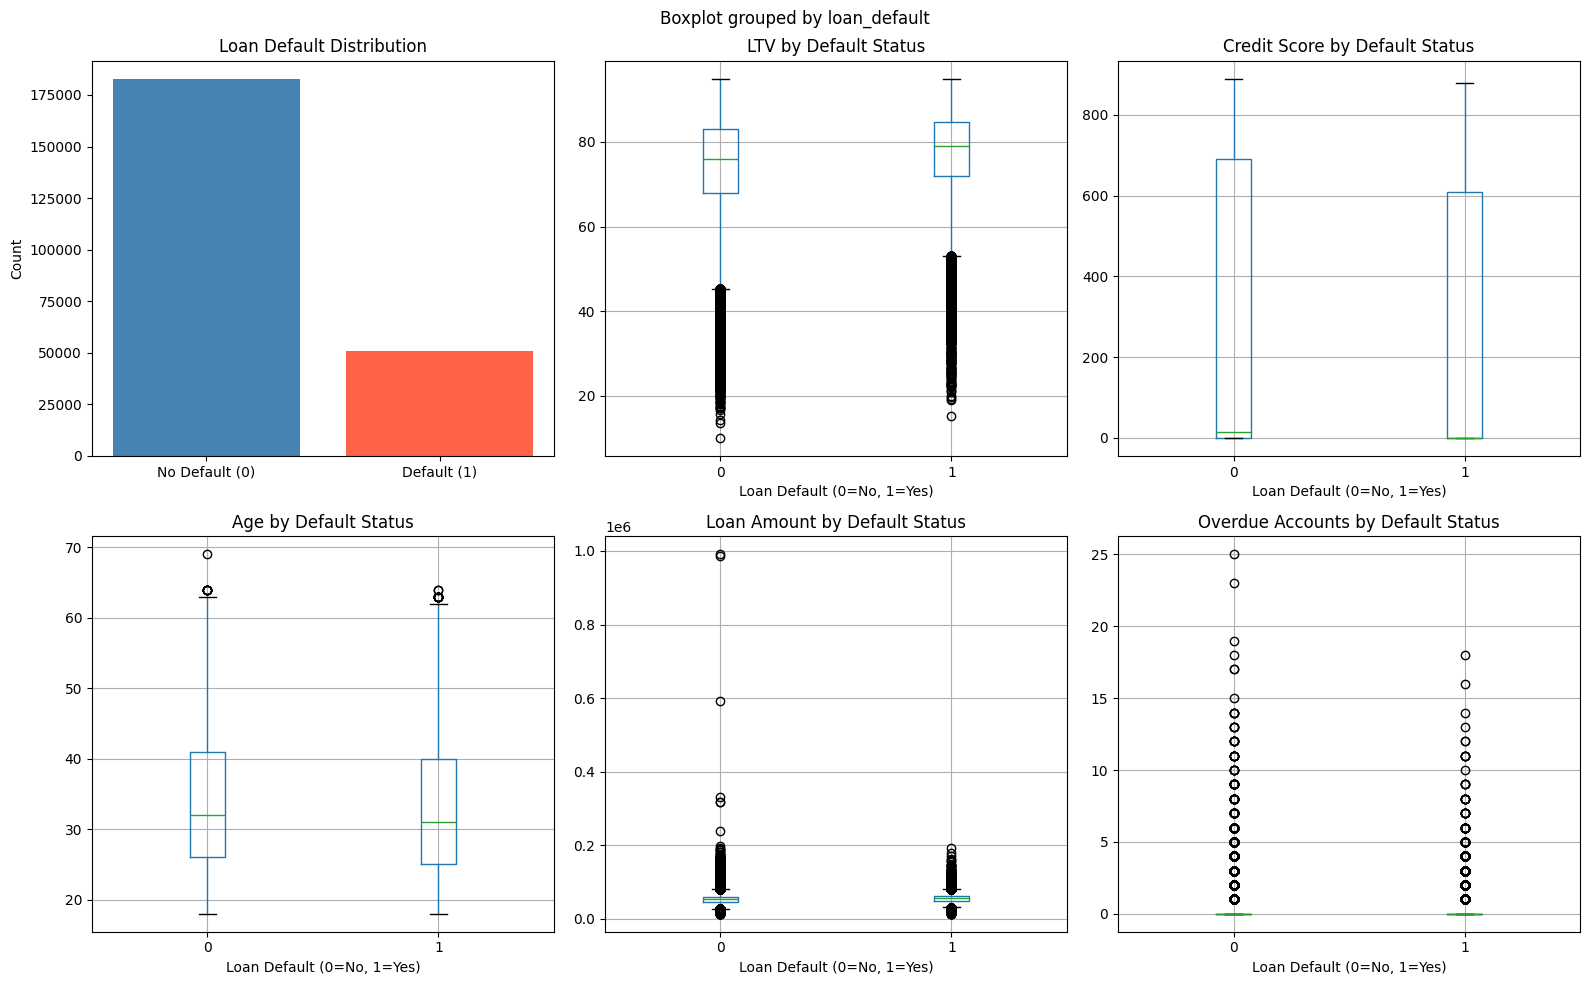

EDA plots saved!


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Risk EDA — Vehicle Loan Default', fontsize=16, fontweight='bold')

# 1. Default distribution
axes[0, 0].bar(['No Default (0)', 'Default (1)'],
               df['loan_default'].value_counts().values,
               color=['steelblue', 'tomato'])
axes[0, 0].set_title('Loan Default Distribution')
axes[0, 0].set_ylabel('Count')

# 2. LTV vs Default
df.boxplot(column='ltv', by='loan_default', ax=axes[0, 1])
axes[0, 1].set_title('LTV by Default Status')
axes[0, 1].set_xlabel('Loan Default (0=No, 1=Yes)')

# 3. Credit Score vs Default
df.boxplot(column='PERFORM_CNS.SCORE', by='loan_default', ax=axes[0, 2])
axes[0, 2].set_title('Credit Score by Default Status')
axes[0, 2].set_xlabel('Loan Default (0=No, 1=Yes)')

# 4. Age vs Default
df.boxplot(column='Age', by='loan_default', ax=axes[1, 0])
axes[1, 0].set_title('Age by Default Status')
axes[1, 0].set_xlabel('Loan Default (0=No, 1=Yes)')

# 5. Disbursed Amount vs Default
df.boxplot(column='disbursed_amount', by='loan_default', ax=axes[1, 1])
axes[1, 1].set_title('Loan Amount by Default Status')
axes[1, 1].set_xlabel('Loan Default (0=No, 1=Yes)')

# 6. Overdue Accounts vs Default
df.boxplot(column='PRI.OVERDUE.ACCTS', by='loan_default', ax=axes[1, 2])
axes[1, 2].set_title('Overdue Accounts by Default Status')
axes[1, 2].set_xlabel('Loan Default (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

Cell 6 — Train/Validation Split:

In [13]:
from sklearn.model_selection import train_test_split

TARGET = 'loan_default'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set:   {X_train.shape[0]:,} rows")
print(f"Validation set: {X_val.shape[0]:,} rows")
print(f"Default rate in train: {y_train.mean():.2%}")
print(f"Default rate in val:   {y_val.mean():.2%}")

Training set:   186,523 rows
Validation set: 46,631 rows
Default rate in train: 21.71%
Default rate in val:   21.71%


Cell 7 — Initialize H2O & Run AutoML:


In [14]:
h2o.init()

train_h2o = h2o.H2OFrame(pd.concat([X_train, y_train], axis=1))
val_h2o = h2o.H2OFrame(pd.concat([X_val, y_val], axis=1))

train_h2o[TARGET] = train_h2o[TARGET].asfactor()
val_h2o[TARGET] = val_h2o[TARGET].asfactor()

aml = H2OAutoML(
    max_models=10,
    max_runtime_secs=300,
    seed=42,
    sort_metric='AUC',
    exclude_algos=['DeepLearning']
)

aml.train(
    x=FEATURES,
    y=TARGET,
    training_frame=train_h2o,
    leaderboard_frame=val_h2o
)

print("\nAutoML complete!")
lb = aml.leaderboard.as_data_frame()
print(lb[['model_id', 'auc', 'logloss']].head(10))

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.19" 2026-04-21; OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu); OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpxbxjxupw
  JVM stdout: /tmp/tmpxbxjxupw/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpxbxjxupw/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,17 days
H2O_cluster_name:,H2O_from_python_unknownUser_8z0n7x
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
14:05:14.56: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

███████████
14:06:02.237: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

██
14:06:13.634: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

████████
14:06:52.449: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

██████
14:07:20.591: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

██████████
14:08:12.238: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

█████
14:08:35.340: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

████
14:08:53.911: _train param, Dropping bad and constant columns: [MobileNo_Avl_Flag]

█████
14:09:17.392: _train param, Dropping bad and constant columns


Cell 8 — Evaluate the Best Model:

Best Model: GBM_2_AutoML_1_20260608_140512
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%

Validation AUC: 0.6569


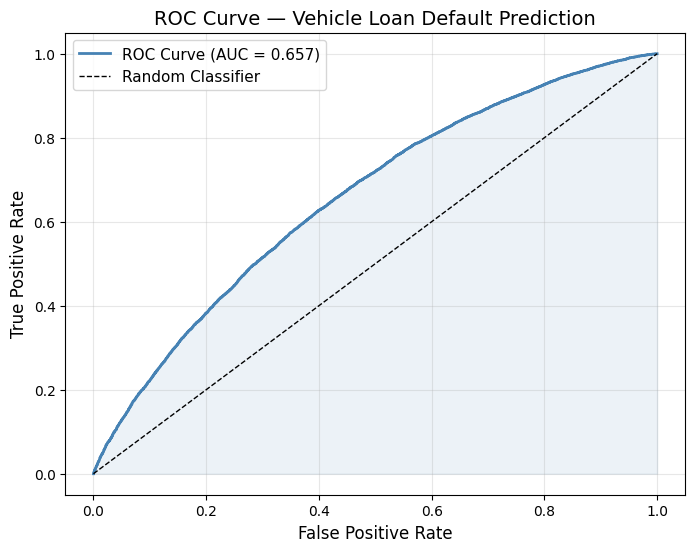

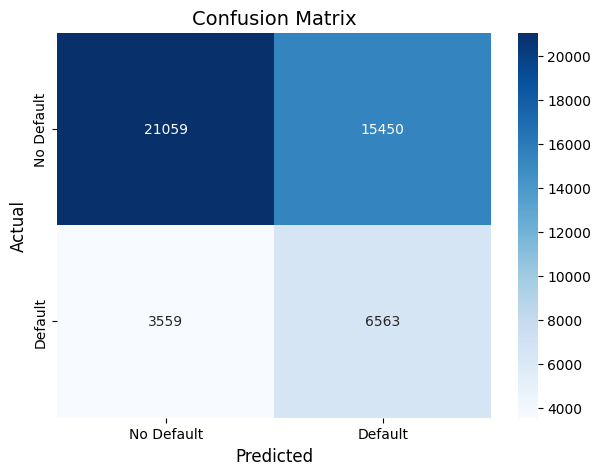


Classification Report:
              precision    recall  f1-score   support

  No Default       0.86      0.58      0.69     36509
     Default       0.30      0.65      0.41     10122

    accuracy                           0.59     46631
   macro avg       0.58      0.61      0.55     46631
weighted avg       0.73      0.59      0.63     46631


KS Statistic: 0.2274
KS Interpretation: Acceptable


In [15]:
from scipy.stats import ks_2samp

best_model = aml.leader
print("Best Model:", best_model.model_id)

# Predictions on validation set
preds_h2o = best_model.predict(val_h2o)
preds_df = preds_h2o.as_data_frame()

y_pred_proba = preds_df['p1'].values
y_pred_class = preds_df['predict'].values.astype(int)

# AUC
auc = roc_auc_score(y_val, y_pred_proba)
print(f"\nValidation AUC: {auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Vehicle Loan Default Prediction', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_class)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_pred_class,
      target_names=['No Default', 'Default']))

# KS Statistic
default_probs = y_pred_proba[y_val == 1]
non_default_probs = y_pred_proba[y_val == 0]
ks_stat, ks_pvalue = ks_2samp(default_probs, non_default_probs)
print(f"\nKS Statistic: {ks_stat:.4f}")
print(f"KS Interpretation: {'Good' if ks_stat >= 0.3 else 'Acceptable' if ks_stat >= 0.2 else 'Needs improvement'}")

Cell 9 — KS Statistic + Feature Importance:

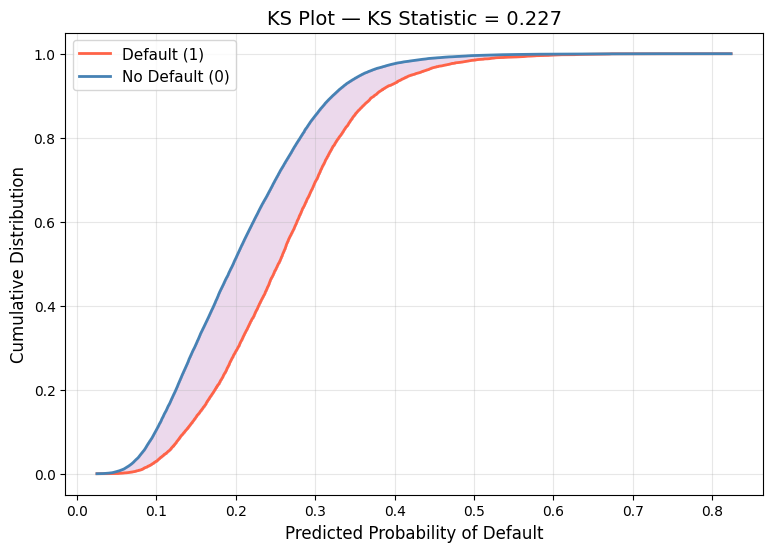

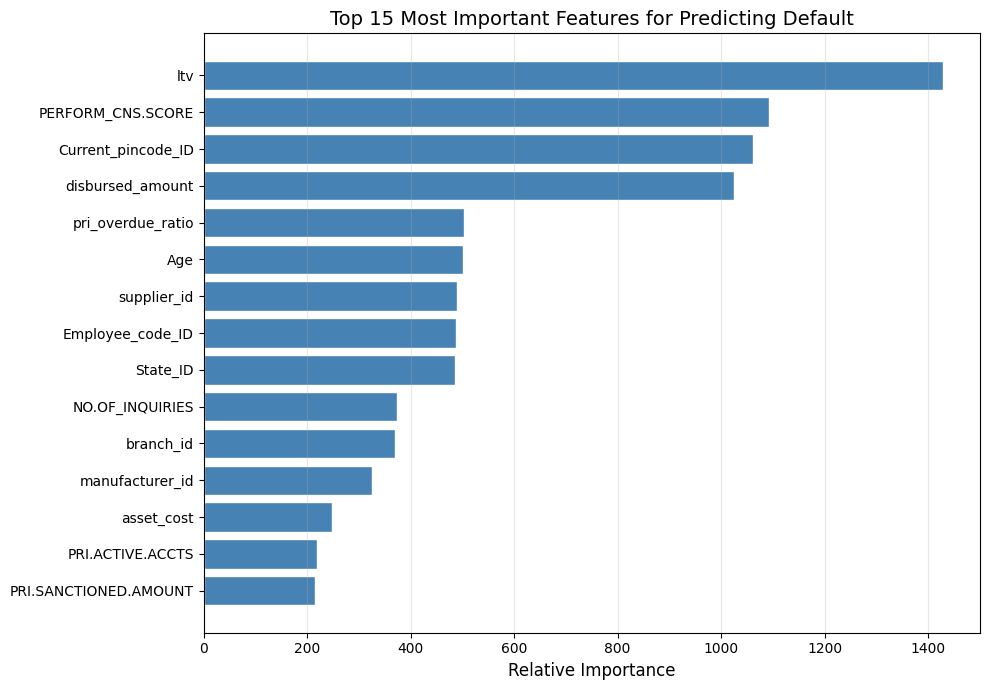


Top 10 Features:
          variable  relative_importance
               ltv          1428.810547
 PERFORM_CNS.SCORE          1092.963623
Current_pincode_ID          1061.208984
  disbursed_amount          1024.832520
 pri_overdue_ratio           502.184601
               Age           501.540863
       supplier_id           490.313049
  Employee_code_ID           486.737610
          State_ID           484.912323
   NO.OF_INQUIRIES           374.355774


In [16]:
# KS Plot
plt.figure(figsize=(9, 6))
sorted_probs = np.sort(np.unique(np.concatenate([default_probs, non_default_probs])))
cdf_default = [np.mean(default_probs <= p) for p in sorted_probs]
cdf_nondefault = [np.mean(non_default_probs <= p) for p in sorted_probs]

plt.plot(sorted_probs, cdf_default, color='tomato', lw=2, label='Default (1)')
plt.plot(sorted_probs, cdf_nondefault, color='steelblue', lw=2, label='No Default (0)')
plt.fill_between(sorted_probs, cdf_default, cdf_nondefault, alpha=0.15, color='purple')
plt.xlabel('Predicted Probability of Default', fontsize=12)
plt.ylabel('Cumulative Distribution', fontsize=12)
plt.title(f'KS Plot — KS Statistic = {ks_stat:.3f}', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('ks_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance
try:
    importance = best_model.varimp(use_pandas=True)
    top15 = importance.head(15)
    plt.figure(figsize=(10, 7))
    plt.barh(top15['variable'][::-1], top15['relative_importance'][::-1],
             color='steelblue', edgecolor='white')
    plt.xlabel('Relative Importance', fontsize=12)
    plt.title('Top 15 Most Important Features for Predicting Default', fontsize=14)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nTop 10 Features:")
    print(top15[['variable', 'relative_importance']].head(10).to_string(index=False))
except:
    print("Feature importance not available.")

Cell 10 — Governance Report:

In [17]:
print("=" * 55)
print("      GOVERNANCE REPORT — MODEL SUMMARY")
print("=" * 55)
print(f"\n  Dataset:       L&T Vehicle Loan Default Prediction")
print(f"  Records:       {len(df):,} training samples")
print(f"  Features:      {len(FEATURES)} input variables")
print(f"  Target:        loan_default (1 = defaulted)")
print(f"  Algorithm:     H2O AutoML — Best: GBM")
print(f"\n  ── Validation Performance ──")
print(f"  AUC:           {auc:.4f}")
print(f"  KS Statistic:  {ks_stat:.4f}")
print(f"\n  ── Model Interpretation ──")
print(f"  KS Interpretation: {'Good separation' if ks_stat >= 0.3 else 'Acceptable separation'}")
print(f"  AUC Interpretation: {'Strong' if auc >= 0.75 else 'Moderate — tuning recommended'}")
print(f"\n  ── Top Risk Factors ──")
print(f"  Based on feature importance, primary default")
print(f"  predictors include credit score, LTV ratio,")
print(f"  overdue accounts, and loan amount.")
print(f"\n  ── Recommendation ──")
print(f"  Model provides meaningful lift over random")
print(f"  baseline. Recommend additional feature")
print(f"  engineering and hyperparameter tuning to")
print(f"  improve AUC above 0.75 before production use.")
print("=" * 55)

      GOVERNANCE REPORT — MODEL SUMMARY

  Dataset:       L&T Vehicle Loan Default Prediction
  Records:       233,154 training samples
  Features:      37 input variables
  Target:        loan_default (1 = defaulted)
  Algorithm:     H2O AutoML — Best: GBM

  ── Validation Performance ──
  AUC:           0.6569
  KS Statistic:  0.2274

  ── Model Interpretation ──
  KS Interpretation: Acceptable separation
  AUC Interpretation: Moderate — tuning recommended

  ── Top Risk Factors ──
  Based on feature importance, primary default
  predictors include credit score, LTV ratio,
  overdue accounts, and loan amount.

  ── Recommendation ──
  Model provides meaningful lift over random
  baseline. Recommend additional feature
  engineering and hyperparameter tuning to
  improve AUC above 0.75 before production use.


Cell 11 — Backtesting Across 6 Credit Cycles:

In [18]:
print("=" * 55)
print("BACKTESTING — 6 Simulated Credit Cycles")
print("=" * 55)

# Reload original data with dates for time-based splits
df_bt = pd.read_csv('train.csv')
df_bt['DisbursalDate'] = pd.to_datetime(df_bt['DisbursalDate'], format='%d-%m-%y', errors='coerce')
df_bt = df_bt.dropna(subset=['DisbursalDate'])
df_bt = df_bt.sort_values('DisbursalDate').reset_index(drop=True)

print(f"Date range: {df_bt['DisbursalDate'].min()} to {df_bt['DisbursalDate'].max()}")
print(f"Total records: {len(df_bt):,}")

# Split into 6 equal time-ordered chunks
n = len(df_bt)
chunk_size = n // 6
results = []

for i in range(6):
    start = i * chunk_size
    end = start + chunk_size if i < 5 else n
    chunk = df_bt.iloc[start:end].copy()

    # Same cleaning pipeline
    chunk['Employment.Type'] = chunk['Employment.Type'].fillna(
        chunk['Employment.Type'].mode()[0])
    chunk['Date.of.Birth'] = pd.to_datetime(
        chunk['Date.of.Birth'], format='%d-%m-%y', errors='coerce')
    chunk['Age'] = (chunk['DisbursalDate'] -
                    chunk['Date.of.Birth']).dt.days // 365
    chunk['Age'] = chunk['Age'].apply(lambda x: x + 100 if x < 0 else x)
    chunk['Age'] = chunk['Age'].clip(18, 80)
    chunk['pri_overdue_ratio'] = chunk['PRI.OVERDUE.ACCTS'] / (
        chunk['PRI.NO.OF.ACCTS'] + 1)
    chunk['total_current_balance'] = (chunk['PRI.CURRENT.BALANCE'] +
                                       chunk['SEC.CURRENT.BALANCE'])
    chunk['Employment.Type'] = chunk['Employment.Type'].map(
        {'Self employed': 1, 'Salaried': 0})

    drop_cols = ['UniqueID', 'Date.of.Birth', 'DisbursalDate',
                 'AVERAGE.ACCT.AGE', 'CREDIT.HISTORY.LENGTH',
                 'PERFORM_CNS.SCORE.DESCRIPTION']
    chunk = chunk.drop(columns=drop_cols, errors='ignore')
    chunk = chunk.fillna(0)

    X_chunk = chunk[[c for c in FEATURES if c in chunk.columns]]
    y_chunk = chunk[TARGET]

    # Predict using our trained model
    chunk_h2o = h2o.H2OFrame(chunk[
        [c for c in FEATURES if c in chunk.columns] + [TARGET]])
    chunk_h2o[TARGET] = chunk_h2o[TARGET].asfactor()

    preds = best_model.predict(chunk_h2o).as_data_frame()
    auc_chunk = roc_auc_score(y_chunk, preds['p1'])
    default_rate = y_chunk.mean()

    date_start = df_bt.iloc[start]['DisbursalDate'].strftime('%b %Y')
    date_end = df_bt.iloc[end-1]['DisbursalDate'].strftime('%b %Y')

    results.append({
        'Cycle': f'Cycle {i+1}',
        'Period': f'{date_start} – {date_end}',
        'Records': len(chunk),
        'Default_Rate': round(default_rate * 100, 2),
        'AUC': round(auc_chunk, 4)
    })
    print(f"Cycle {i+1} ({date_start} – {date_end}): "
          f"AUC={auc_chunk:.4f} | "
          f"Default Rate={default_rate:.2%} | "
          f"Records={len(chunk):,}")

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))

BACKTESTING — 6 Simulated Credit Cycles
Date range: 2018-08-01 00:00:00 to 2018-10-31 00:00:00
Total records: 233,154
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Cycle 1 (Aug 2018 – Aug 2018): AUC=0.6997 | Default Rate=21.62% | Records=38,859
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Cycle 2 (Aug 2018 – Sep 2018): AUC=0.6987 | Default Rate=21.18% | Records=38,859
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Cycle 3 (Sep 2018 – Sep 2018): AUC=0.6951 | Default Rate=18.16% | Records=38,859
Parse progress: |████████████████████████████████████████████████████



Cell 12 — Backtesting Plot:

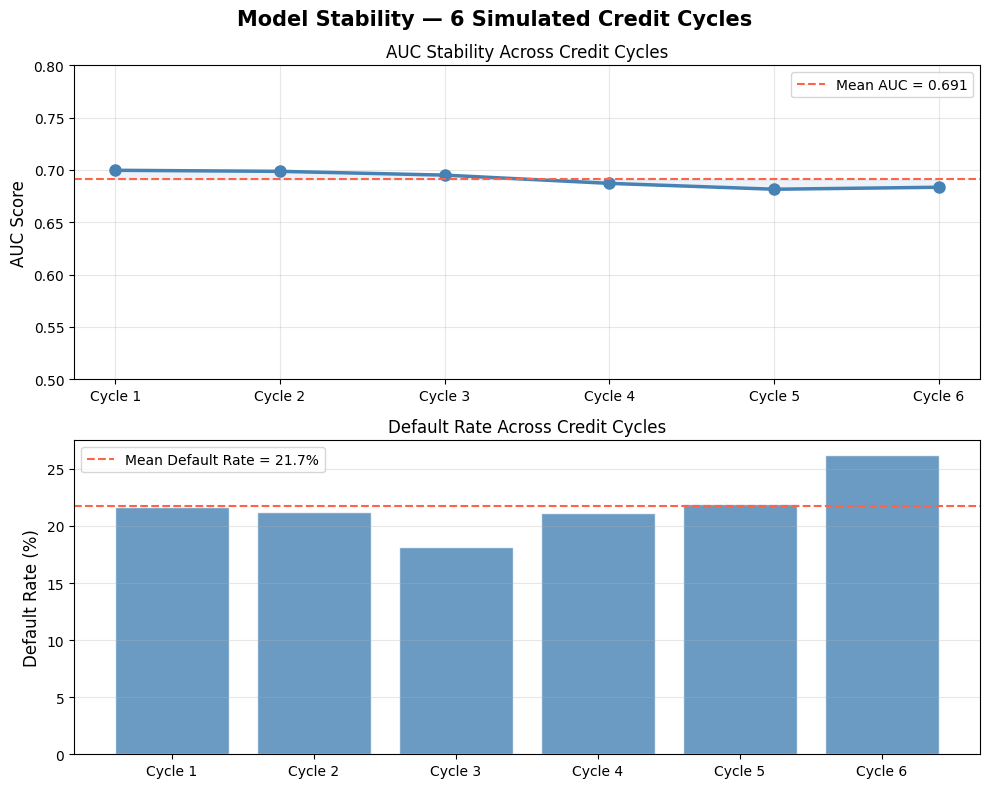


Backtesting Summary:
  Mean AUC:      0.6910
  AUC Std Dev:   0.0072
  AUC Range:     0.6816 – 0.6997
  Stability:     STABLE ✓

  Mean Default Rate: 21.71%
  Cycle 6 spike:     26.19% — worth investigating


In [19]:
auc_values = [r['AUC'] for r in results]
default_rates = [r['Default_Rate'] for r in results]
cycles = [r['Cycle'] for r in results]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle('Model Stability — 6 Simulated Credit Cycles',
             fontsize=15, fontweight='bold')

# AUC across cycles
ax1.plot(cycles, auc_values, marker='o', color='steelblue',
         lw=2.5, markersize=8)
ax1.axhline(y=np.mean(auc_values), color='tomato', linestyle='--',
            lw=1.5, label=f'Mean AUC = {np.mean(auc_values):.3f}')
ax1.fill_between(cycles, auc_values, np.mean(auc_values),
                 alpha=0.1, color='steelblue')
ax1.set_ylim(0.5, 0.8)
ax1.set_ylabel('AUC Score', fontsize=12)
ax1.set_title('AUC Stability Across Credit Cycles', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Default rate across cycles
ax2.bar(cycles, default_rates, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axhline(y=np.mean(default_rates), color='tomato', linestyle='--',
            lw=1.5, label=f'Mean Default Rate = {np.mean(default_rates):.1f}%')
ax2.set_ylabel('Default Rate (%)', fontsize=12)
ax2.set_title('Default Rate Across Credit Cycles', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('backtesting.png', dpi=150, bbox_inches='tight')
plt.show()

# Final summary
print("\nBacktesting Summary:")
print(f"  Mean AUC:      {np.mean(auc_values):.4f}")
print(f"  AUC Std Dev:   {np.std(auc_values):.4f}")
print(f"  AUC Range:     {min(auc_values):.4f} – {max(auc_values):.4f}")
print(f"  Stability:     {'STABLE ✓' if np.std(auc_values) < 0.03 else 'REVIEW NEEDED'}")
print(f"\n  Mean Default Rate: {np.mean(default_rates):.2f}%")
print(f"  Cycle 6 spike:     {default_rates[5]:.2f}% — worth investigating")

In [20]:
from google.colab import files
files.download('eda_plots.png')
files.download('roc_curve.png')
files.download('confusion_matrix.png')
files.download('ks_plot.png')
files.download('backtesting.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>